In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,StratifiedKFold
from sklearn.metrics import  confusion_matrix, classification_report, accuracy_score, auc, precision_recall_curve, f1_score, precision_score, recall_score
from catboost import CatBoostClassifier

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/Colab/Assessment/BKT- Tires- Data Science Churn or Retain/train.csv")
labels = pd.read_csv("/content/drive/MyDrive/Colab/Assessment/BKT- Tires- Data Science Churn or Retain/train_labels.csv")
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",None)

# EDA - Exporatory Data Analysis

In [ ]:
print(data.head())
print(labels.head())

   Var1  Var2  Var3  Var4  Var5    Var6  Var7  Var8  Var9  Var10  Var11  \
0   NaN   NaN   NaN   NaN   NaN  1526.0   7.0   NaN   NaN    NaN    NaN   
1   NaN   NaN   NaN   NaN   NaN   525.0   0.0   NaN   NaN    NaN    NaN   
2   NaN   NaN   NaN   NaN   NaN  5236.0   7.0   NaN   NaN    NaN    NaN   
3   NaN   NaN   NaN   NaN   NaN     NaN   0.0   NaN   NaN    NaN    NaN   
4   NaN   NaN   NaN   NaN   NaN  1029.0   7.0   NaN   NaN    NaN    NaN   

   Var12   Var13  Var14  Var15  Var16  Var17  Var18  Var19  Var20   Var21  \
0    NaN   184.0    NaN    NaN    NaN    NaN    NaN    NaN    NaN   464.0   
1    NaN     0.0    NaN    NaN    NaN    NaN    NaN    NaN    NaN   168.0   
2    NaN   904.0    NaN    NaN    NaN    NaN    NaN    NaN    NaN  1212.0   
3    NaN     0.0    NaN    NaN    NaN    NaN    NaN    NaN    NaN     NaN   
4    NaN  3216.0    NaN    NaN    NaN    NaN    NaN    NaN    NaN    64.0   

    Var22  Var23  Var24  Var25  Var26  Var27   Var28  Var29  Var30  Var31  \
0   580.0

In [ ]:
print(data.shape)
print(labels.shape)

(50000, 230)
(50000, 1)


In [ ]:
data.isnull().sum()

,0
Var1,49298
Var2,48759
Var3,48760
Var4,48421
Var5,48513
Var6,5529
Var7,5539
Var8,50000
Var9,49298
Var10,48513


In [ ]:
labels.value_counts()

,count
Label,
-1,46328
1,3672


In [ ]:
data.dtypes.value_counts()

,count
float64,191
object,38
int64,1


In [ ]:
categorical_cols = data.select_dtypes(include="object").columns

len(categorical_cols)

38

In [ ]:
df = data.copy()
df["targets"] = labels


In [ ]:
df['targets'].value_counts(normalize=True) *100

,proportion
targets,
-1,92.656
1,7.344


In [ ]:
missing_pct = (df.isnull().mean() *100).sort_values(ascending = False)
missing_pct

,0
Var20,100.000
Var39,100.000
Var32,100.000
Var31,100.000
Var8,100.000
Var15,100.000
Var42,100.000
Var48,100.000
Var52,100.000
Var55,100.000


In [ ]:
(df.isnull().mean() * 100 == 100).value_counts() # Columns null 100%  {Extreme Missingness}

,count
False,213
True,18


In [ ]:
for col in categorical_cols:
  print(f"{col} - ",df[col].nunique())

Var191 -  1
Var192 -  361
Var193 -  51
Var194 -  3
Var195 -  23
Var196 -  4
Var197 -  225
Var198 -  4291
Var199 -  5073
Var200 -  15415
Var201 -  2
Var202 -  5713
Var203 -  5
Var204 -  100
Var205 -  3
Var206 -  21
Var207 -  14
Var208 -  2
Var210 -  6
Var211 -  2
Var212 -  81
Var213 -  1
Var214 -  15415
Var215 -  1
Var216 -  2016
Var217 -  13990
Var218 -  2
Var219 -  22
Var220 -  4291
Var221 -  7
Var222 -  4291
Var223 -  4
Var224 -  1
Var225 -  3
Var226 -  23
Var227 -  7
Var228 -  30
Var229 -  4


In [ ]:
for i in ['Var201',	'Var194',	'Var189',	'Var229',	'Var225']: #74.434,74.432,57.956,56.864,52.288
  print(df.groupby('targets')[i].apply(lambda x:x.isna().mean() * 100))

targets
-1    74.190554
 1    77.505447
Name: Var201, dtype: float64
targets
-1    74.188396
 1    77.505447
Name: Var194, dtype: float64
targets
-1    58.023226
 1    57.107843
Name: Var189, dtype: float64
targets
-1    56.024434
 1    67.456427
Name: Var229, dtype: float64
targets
-1    51.543343
 1    61.683007
Name: Var225, dtype: float64


In [ ]:
missing_pct.describe()

,0
count,231.000000
mean,69.473177
std,41.712009
min,0.000000
25%,11.068000
50%,97.026000
75%,98.596000
max,100.000000


In [ ]:
df.nunique().sort_values(ascending=True)

,0
Var8,0
Var15,0
Var31,0
Var20,0
Var32,0
Var48,0
Var42,0
Var39,0
Var52,0
Var55,0


In [ ]:
numerical_cols = [col for col in df.columns if df[col].dtype == np.float64]

In [ ]:
numerical_cols = [col for col in df.columns if df[col].dtype == np.float64]
numerical_cols

['Var1',
 'Var2',
 'Var3',
 'Var4',
 'Var5',
 'Var6',
 'Var7',
 'Var8',
 'Var9',
 'Var10',
 'Var11',
 'Var12',
 'Var13',
 'Var14',
 'Var15',
 'Var16',
 'Var17',
 'Var18',
 'Var19',
 'Var20',
 'Var21',
 'Var22',
 'Var23',
 'Var24',
 'Var25',
 'Var26',
 'Var27',
 'Var28',
 'Var29',
 'Var30',
 'Var31',
 'Var32',
 'Var33',
 'Var34',
 'Var35',
 'Var36',
 'Var37',
 'Var38',
 'Var39',
 'Var40',
 'Var41',
 'Var42',
 'Var43',
 'Var44',
 'Var45',
 'Var46',
 'Var47',
 'Var48',
 'Var49',
 'Var50',
 'Var51',
 'Var52',
 'Var53',
 'Var54',
 'Var55',
 'Var56',
 'Var57',
 'Var58',
 'Var59',
 'Var60',
 'Var61',
 'Var62',
 'Var63',
 'Var64',
 'Var65',
 'Var66',
 'Var67',
 'Var68',
 'Var69',
 'Var70',
 'Var71',
 'Var72',
 'Var74',
 'Var75',
 'Var76',
 'Var77',
 'Var78',
 'Var79',
 'Var80',
 'Var81',
 'Var82',
 'Var83',
 'Var84',
 'Var85',
 'Var86',
 'Var87',
 'Var88',
 'Var89',
 'Var90',
 'Var91',
 'Var92',
 'Var93',
 'Var94',
 'Var95',
 'Var96',
 'Var97',
 'Var98',
 'Var99',
 'Var100',
 'Var101',
 'Var10

In [ ]:
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
constant_cols

['Var8',
 'Var15',
 'Var20',
 'Var31',
 'Var32',
 'Var39',
 'Var42',
 'Var48',
 'Var52',
 'Var55',
 'Var79',
 'Var118',
 'Var141',
 'Var167',
 'Var169',
 'Var175',
 'Var185',
 'Var191',
 'Var209',
 'Var213',
 'Var215',
 'Var224',
 'Var230']

In [ ]:
null_cols = [col for col in df.columns if df[col].isna().mean() *100 == 100]
null_cols

['Var8',
 'Var15',
 'Var20',
 'Var31',
 'Var32',
 'Var39',
 'Var42',
 'Var48',
 'Var52',
 'Var55',
 'Var79',
 'Var141',
 'Var167',
 'Var169',
 'Var175',
 'Var185',
 'Var209',
 'Var230']

In [ ]:
target_means = (
    df.groupby("targets")
      .mean(numeric_only=True)
      .T
)

target_means["diff"] = (
    target_means[1]
    - target_means[-1]
)

target_means["abs_diff"] = (
    target_means["diff"].abs()
)

target_means.sort_values(
    "abs_diff",
    ascending=False
).head(20)

targets,-1,1,diff,abs_diff
Var131,3.604389e+06,1.078799e+07,7.183604e+06,7.183604e+06
Var69,3.490814e+06,4.377225e+06,8.864110e+05,8.864110e+05
Var177,6.024150e+05,9.809972e+05,3.785822e+05,3.785822e+05
Var154,1.558226e+06,1.246140e+06,-3.120863e+05,3.120863e+05
Var53,6.363097e+05,9.173720e+05,2.810623e+05,2.810623e+05
Var114,5.971536e+05,8.494671e+05,2.523135e+05,2.523135e+05
Var153,6.168303e+06,6.347433e+06,1.791298e+05,1.791298e+05
Var180,3.787043e+06,3.626537e+06,-1.605061e+05,1.605061e+05
Var113,-1.648203e+05,-7.662741e+03,1.571575e+05,1.571575e+05
Var139,1.751240e+05,3.134227e+05,1.382987e+05,1.382987e+05


In [ ]:
cols = [
    "Var113",
    "Var81",
    "Var133",
    "Var153"
] # Extreme unique values
for col in cols:
  print(df[col].value_counts().head(10))

Var113
 0.0         951
-80196.8       3
 114611.6      3
 118363.6      3
 45211.2       3
 90802.0       2
 142083.2      2
 58520.0       2
 134688.8      2
 166700.4      2
Name: count, dtype: int64
Var81
0.0         666
259200.0      4
221039.1      3
198568.2      3
202639.2      3
234340.2      3
216573.0      3
222006.3      3
183267.3      3
191281.8      3
Name: count, dtype: int64
Var133
0.0           3848
9504000.0      321
3024000.0      138
6048000.0      124
1296000.0      116
9072000.0      107
8208000.0       83
3888000.0       73
12096000.0      63
432000.0        61
Name: count, dtype: int64
Var153
0.0           2221
10368000.0     246
10713600.0     122
9676800.0      117
10022400.0      20
10454680.0      19
7257600.0       14
10454800.0      11
10713640.0       9
10771480.0       9
Name: count, dtype: int64


In [ ]:
for col in ["Var131","Var69","Var177","Var154"]:
    print(col)
    print(df.groupby("targets")[col].describe())
    print("-"*50)

Var131
         count          mean           std  min  25%  50%  75%          max
targets                                                                    
-1       657.0  3.604389e+06  1.971188e+07  0.0  0.0  0.0  0.0  318676000.0
 1        45.0  1.078799e+07  6.606760e+07  0.0  0.0  0.0  0.0  442233600.0
--------------------------------------------------
Var69
          count          mean           std  min  25%        50%         75%  \
targets                                                                        
-1       1418.0  3.490814e+06  4.897250e+06  0.0  0.0   468256.5  6193316.25   
 1         69.0  4.377225e+06  5.680728e+06  0.0  0.0  1681740.0  8048034.00   

                max  
targets              
-1       18741870.0  
 1       17757540.0  
--------------------------------------------------
Var177
          count           mean           std  min  25%  50%         75%  \
targets                                                                   
-1       1187.0

In [ ]:
print(df["Var131"].count())
print(df["Var131"].describe())

print(df["Var131"].quantile([0.25,0.5,0.75,0.95,0.99]))  # Heavy tailed distribution

702
count    7.020000e+02
mean     4.064877e+06
std      2.531187e+07
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      4.422336e+08
Name: Var131, dtype: float64
0.25           0.0
0.50           0.0
0.75           0.0
0.95    16214348.0
0.99    87192784.0
Name: Var131, dtype: float64


<Axes: xlabel='targets', ylabel='count'>

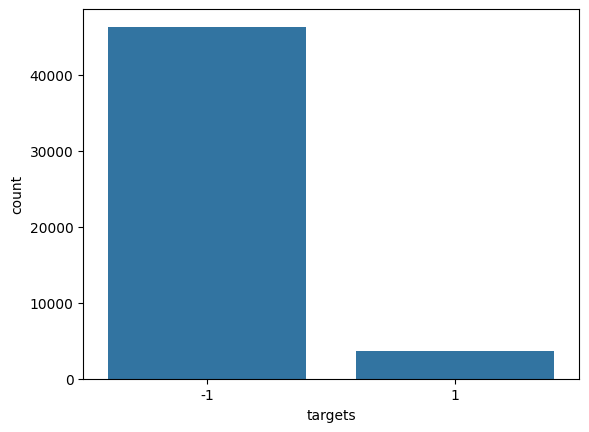

In [ ]:
sns.countplot(x = df['targets'])

<Axes: >

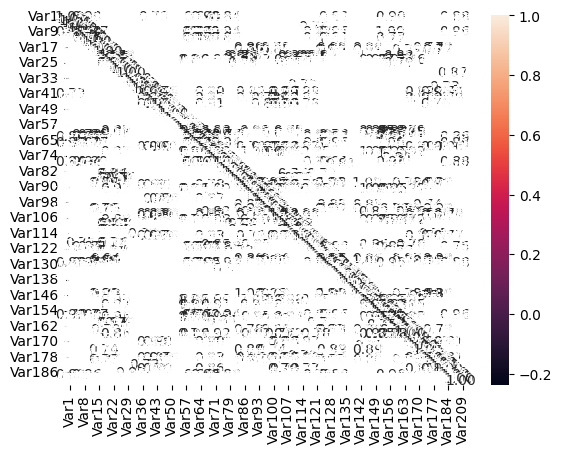

In [ ]:
plt.Figure(figsize=(30,30))
sns.heatmap(df[numerical_cols].corr(),linewidths= 0.2, fmt = '.2f',annot = True)

# Feature Engineering

In [ ]:
drop_cols = list(set(constant_cols + null_cols))
drop_cols

['Var55',
 'Var209',
 'Var20',
 'Var230',
 'Var8',
 'Var31',
 'Var167',
 'Var118',
 'Var52',
 'Var185',
 'Var42',
 'Var213',
 'Var175',
 'Var32',
 'Var215',
 'Var224',
 'Var48',
 'Var15',
 'Var141',
 'Var169',
 'Var39',
 'Var79',
 'Var191']

In [ ]:
df = df.drop(drop_cols,axis=1)
df.shape

(50000, 208)

In [ ]:
categorical_cols = df.select_dtypes(include="object").columns

print(len(categorical_cols))

categorical_cols[:10]

34


Index(['Var192', 'Var193', 'Var194', 'Var195', 'Var196', 'Var197', 'Var198',
       'Var199', 'Var200', 'Var201'],
      dtype='object')

# Model Building

In [ ]:
y = df["targets"]
X = df.drop("targets", axis=1)
print(y.shape)
print(X.shape)

(50000,)
(50000, 207)


In [ ]:
y = y.replace({
    -1: 0,
     1: 1
})

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle= True, random_state= 8)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold}")
    print(len(train_idx))
    print(len(val_idx))
    X_train, X_test = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[val_idx]
    print(f"\nFold {fold}")
    print(X_train.shape)
    print(X_test.shape)

    print("\nTrain Distribution")
    print(y_train.value_counts(normalize=True))

    print("\nValidation Distribution")
    print(y_test.value_counts(normalize=True))

Fold 0
40000
10000

Fold 0
(40000, 207)
(10000, 207)

Train Distribution
targets
0    0.92655
1    0.07345
Name: proportion, dtype: float64

Validation Distribution
targets
0    0.9266
1    0.0734
Name: proportion, dtype: float64
Fold 1
40000
10000

Fold 1
(40000, 207)
(10000, 207)

Train Distribution
targets
0    0.92655
1    0.07345
Name: proportion, dtype: float64

Validation Distribution
targets
0    0.9266
1    0.0734
Name: proportion, dtype: float64
Fold 2
40000
10000

Fold 2
(40000, 207)
(10000, 207)

Train Distribution
targets
0    0.92655
1    0.07345
Name: proportion, dtype: float64

Validation Distribution
targets
0    0.9266
1    0.0734
Name: proportion, dtype: float64
Fold 3
40000
10000

Fold 3
(40000, 207)
(10000, 207)

Train Distribution
targets
0    0.926575
1    0.073425
Name: proportion, dtype: float64

Validation Distribution
targets
0    0.9265
1    0.0735
Name: proportion, dtype: float64
Fold 4
40000
10000

Fold 4
(40000, 207)
(10000, 207)

Train Distribution
targe

In [ ]:
X_train[categorical_cols].dtypes.value_counts()

,count
object,34


In [ ]:
model = CatBoostClassifier(
    iterations= 150,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="F1",
    class_weights=[1, 12.6],   # weight = -1 class / 1 class of targets
    random_seed=42,
    verbose=100
)

In [ ]:
# Uncomment if running for first time
X_train = X_train.copy()
X_test = X_test.copy()

for col in categorical_cols:
    X_train[col] = X_train[col].fillna("Missing").astype(str)
    X_test[col] = X_test[col].fillna("Missing").astype(str)

In [ ]:
# Uncomment if running for first time
X_train[categorical_cols].isnull().sum().sum()

np.int64(0)

In [ ]:
model.fit(
    X_train,
    y_train,
    cat_features=list(categorical_cols),
    eval_set=(X_test, y_test)
)

0:	learn: 0.6444830	test: 0.6046985	best: 0.6046985 (0)	total: 412ms	remaining: 3m 25s
100:	learn: 0.6977213	test: 0.6366903	best: 0.6394047 (96)	total: 43.7s	remaining: 2m 52s
200:	learn: 0.7143810	test: 0.6347970	best: 0.6416077 (131)	total: 1m 22s	remaining: 2m 3s
300:	learn: 0.7458385	test: 0.6285747	best: 0.6416077 (131)	total: 2m 8s	remaining: 1m 24s
400:	learn: 0.7757139	test: 0.6242406	best: 0.6416077 (131)	total: 2m 55s	remaining: 43.3s
499:	learn: 0.8041970	test: 0.6087324	best: 0.6416077 (131)	total: 3m 50s	remaining: 0us

bestTest = 0.6416076593
bestIteration = 131

Shrink model to first 132 iterations.


CatBoostClassifier(class_weights=[1, 12.6], depth=6, eval_metric='F1', iterations=500, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=100)

In [ ]:
preds = model.predict(X_test)


print(confusion_matrix(y_test, preds))
print(classification_report(y_test, preds))

[[6575 2690]
 [ 287  448]]
              precision    recall  f1-score   support

           0       0.96      0.71      0.82      9265
           1       0.14      0.61      0.23       735

    accuracy                           0.70     10000
   macro avg       0.55      0.66      0.52     10000
weighted avg       0.90      0.70      0.77     10000



In [ ]:
probs = model.predict_proba(X_test)[:,1]
print(probs.min())
print(probs.max())
print(probs.mean())

0.057473464974208646
0.9191141671518446
0.4242703411872741


In [ ]:
for threshold in [0.3,0.4,0.5,0.6,0.7,0.8]:

    preds = (probs >= threshold).astype(int)

    print(
        f"Threshold={threshold}"
    )

    print(
        "Precision:",
        round(precision_score(y_test,preds),3)
    )

    print(
        "Recall:",
        round(recall_score(y_test,preds),3)
    )

    print(
        "F1:",
        round(f1_score(y_test,preds),3)
    )

    print("-"*30)

Threshold=0.3
Precision: 0.091
Recall: 0.937
F1: 0.165
------------------------------
Threshold=0.4
Precision: 0.11
Recall: 0.805
F1: 0.194
------------------------------
Threshold=0.5
Precision: 0.143
Recall: 0.61
F1: 0.231
------------------------------
Threshold=0.6
Precision: 0.193
Recall: 0.386
F1: 0.258
------------------------------
Threshold=0.7
Precision: 0.277
Recall: 0.192
F1: 0.227
------------------------------
Threshold=0.8
Precision: 0.41
Recall: 0.044
F1: 0.079
------------------------------


{}